# Quantum Fourier Transform

In [1]:
import math
import numpy as np

from numpy import pi
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import CPhaseGate, HGate, XGate, SwapGate
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import StatevectorSimulator, AerSimulator
from qiskit.compiler import transpile

In [2]:
import qiskit

qiskit.__version__

'2.1.2'

![QFT](./images/qft.png)

$$
U_k \;=\;
\begin{pmatrix}
1 & 0\\
0 & e^{\,2\pi i / 2^k}
\end{pmatrix}
\;=\;
\begin{pmatrix}
1 & 0\\
0 & e^{\,i\theta_{k,j}}
\end{pmatrix},
\qquad
\theta_{k,j}=\frac{2\pi}{2^{\,k-j+1}}=\frac{\pi}{2^{\,k-j}},\qquad (k>j).
$$


In [3]:
def QFT(n):
    q = QuantumRegister(n, 'q')
    qft_circuit = QuantumCircuit(q, name='QFT '+str(n))
    
    for i in range(len(q)): 
        qft_circuit.append(HGate(), [q[i]])
        
        for k in range(i+1, len(q)):
            controlled_phase_gate = CPhaseGate(pi/(2**(k-i))) 
            qft_circuit.append(controlled_phase_gate, [q[k], q[i]])
        
        qft_circuit.barrier()

    for i in range(math.floor(len(q)/2)):
        qft_circuit.append(SwapGate(), [q[i], q[len(q)-i-1]])

    return qft_circuit

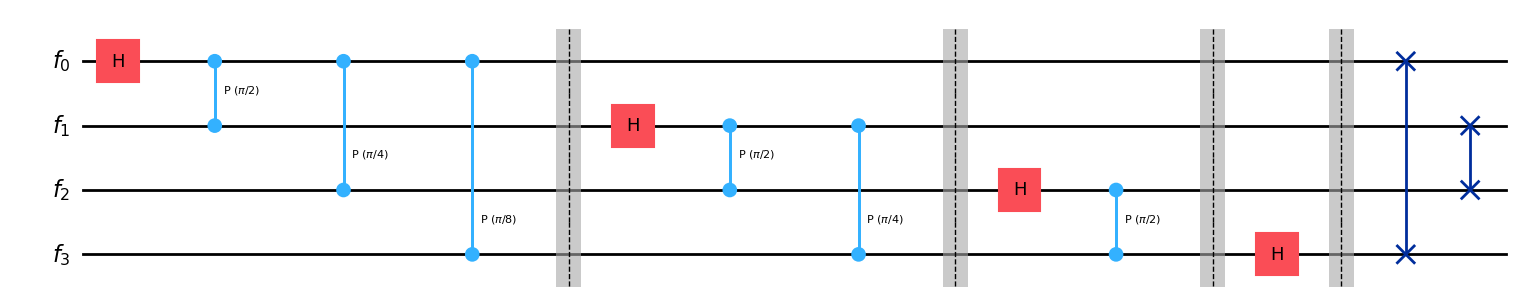

In [4]:
n = 4
f = QuantumRegister(n, 'f')
qft_circuit = QuantumCircuit(f, name='QFT '+str(n))
qft_circuit.append(QFT(len(f)), f[0:])
qft_circuit.decompose().draw('mpl')

In [5]:
def encode_bin_value(bin_value):
    q = QuantumRegister(len(bin_value))
    qc_value = QuantumCircuit(q, name='encode: '+bin_value)
    
    for i in range(len(bin_value)):
        if int(bin_value[i]):
            qc_value.append(XGate(), [q[i]])
    
    #return qc_value
    return qc_value.reverse_bits() # reverse because qiskit uses little endian convention

    

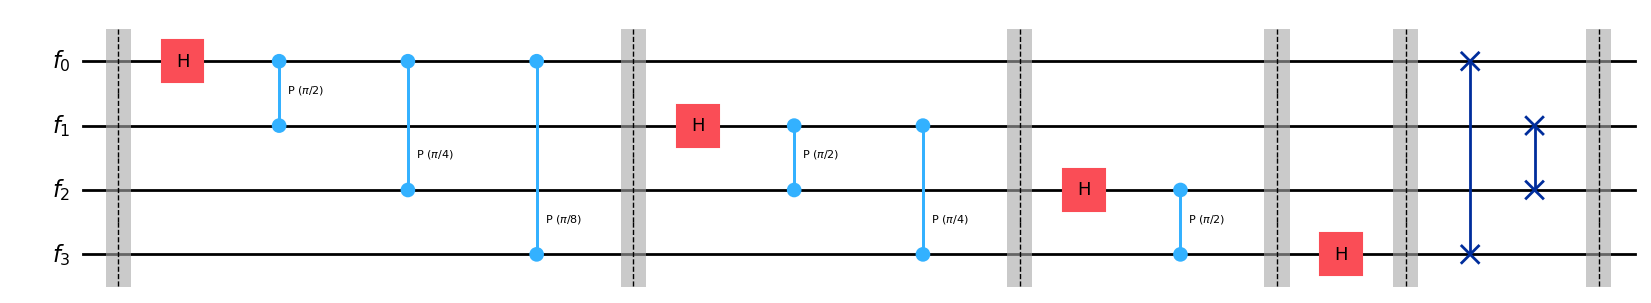

In [6]:
n = 4

f = QuantumRegister(n, 'f')

qft_circuit = QuantumCircuit(f, name='QFT '+str(n))

bin_value = '0000'
qft_circuit.append(encode_bin_value(bin_value), f[0:])

qft_circuit.barrier()
    
qft_circuit.append(QFT(len(f)), f[0:])

qft_circuit.barrier()

qft_circuit.decompose().draw('mpl')

In [7]:
simulator = StatevectorSimulator()  # Create a simulator backend
transpiled_qft_circuit = transpile(qft_circuit, simulator)
result_qft = simulator.run(transpiled_qft_circuit).result()  # Run the circuit and get the result
statevector_qft = result_qft.get_statevector() 
print(np.asarray(statevector_qft).real)

[0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25
 0.25 0.25]


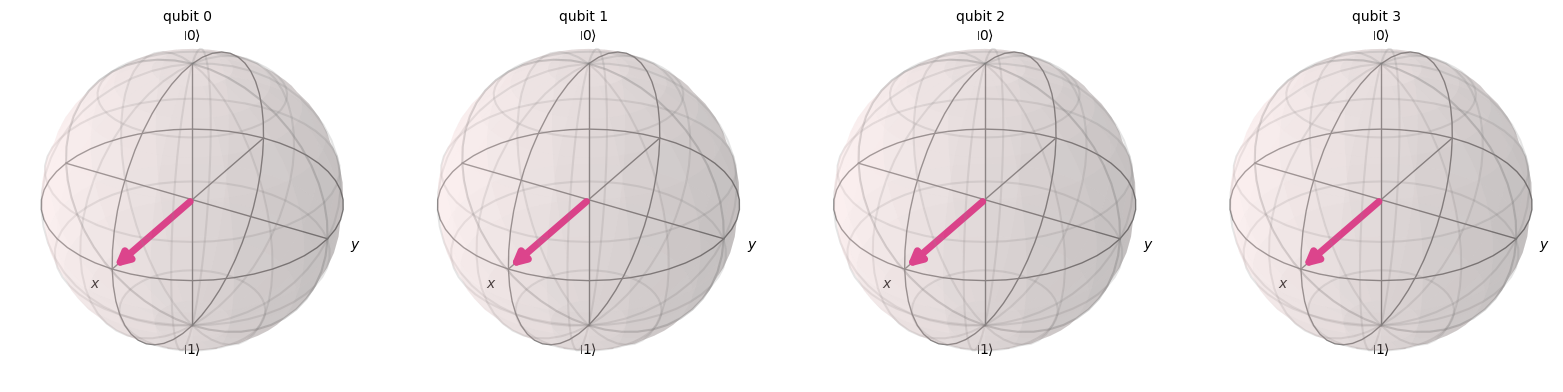

In [8]:
plot_bloch_multivector(statevector_qft)

Binary Value: 1110


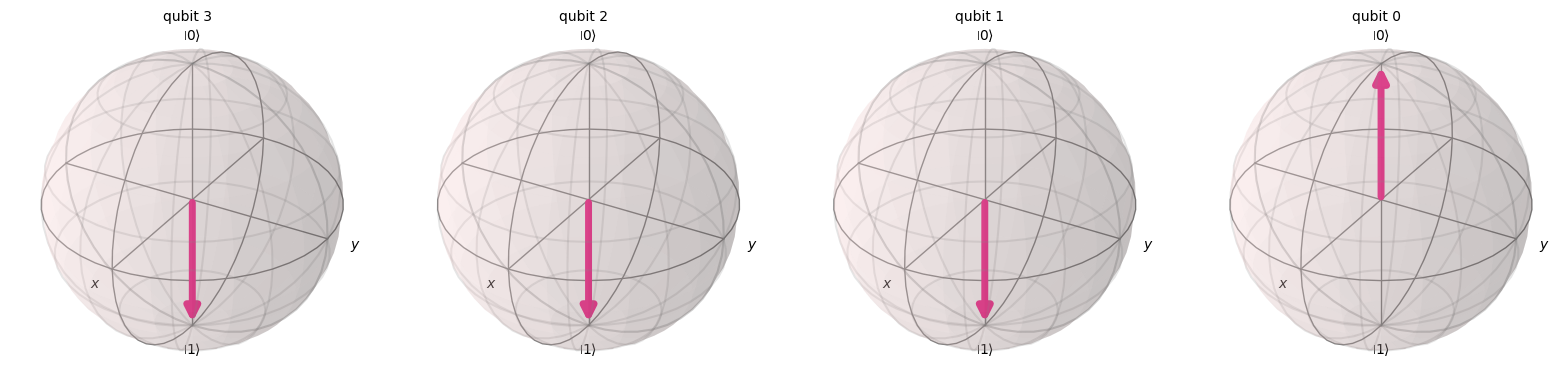

Binary Value in the Fourier basis:


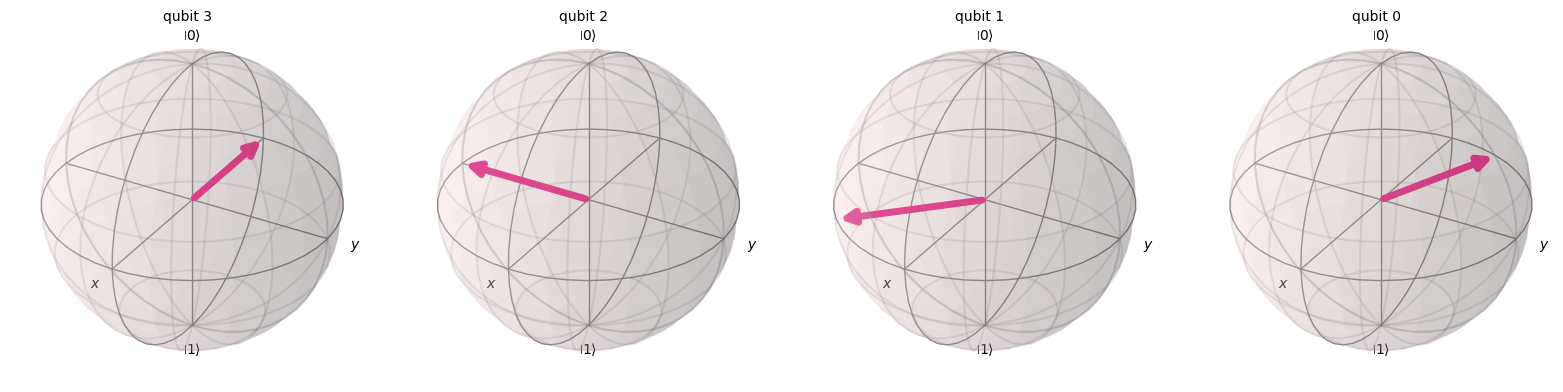

In [10]:
bin_value = '1110'
n = len(bin_value)

b = QuantumRegister(n, 'b')
qc_basis = QuantumCircuit(b, name='Basis '+str(n))
qc_basis.append(encode_bin_value(bin_value), b[0:])

simulator = StatevectorSimulator()  # Create a simulator backend
transpiled_qc_basis = transpile(qc_basis, simulator)
result_basis = simulator.run(transpiled_qc_basis).result()  # Run the circuit and get the result
statevector_basis = result_basis.get_statevector() 


f = QuantumRegister(n, 'f')
qft_circuit = QuantumCircuit(f, name='QFT '+str(n))
qft_circuit.append(encode_bin_value(bin_value), f[0:])
qft_circuit.append(QFT(len(f)), f[0:])


simulator = StatevectorSimulator()  # Create a simulator backend
transpiled_qft_circuit = transpile(qft_circuit, simulator)
result_qft = simulator.run(transpiled_qft_circuit).result()  # Run the circuit and get the result
statevector_qft = result_qft.get_statevector() 
plot_bloch_multivector(statevector_qft)

print(f'Binary Value: {bin_value}')
display(plot_bloch_multivector(statevector_basis, reverse_bits=True))
print(f'Binary Value in the Fourier basis:')
display(plot_bloch_multivector(statevector_qft, reverse_bits=True))

In [11]:
print(statevector_qft)

Statevector([ 2.50000000e-01-9.18485099e-17j,
             -2.30969883e-01+9.56708581e-02j,
              1.76776695e-01-1.76776695e-01j,
             -9.56708581e-02+2.30969883e-01j,
             -1.07156595e-16-2.50000000e-01j,
              9.56708581e-02+2.30969883e-01j,
             -1.76776695e-01-1.76776695e-01j,
              2.30969883e-01+9.56708581e-02j,
             -2.50000000e-01+9.18485099e-17j,
              2.30969883e-01-9.56708581e-02j,
             -1.76776695e-01+1.76776695e-01j,
              9.56708581e-02-2.30969883e-01j,
              1.07156595e-16+2.50000000e-01j,
             -9.56708581e-02-2.30969883e-01j,
              1.76776695e-01+1.76776695e-01j,
             -2.30969883e-01-9.56708581e-02j],
            dims=(2, 2, 2, 2))


<h2> Comparison with Qiskit QFTGate<h2>

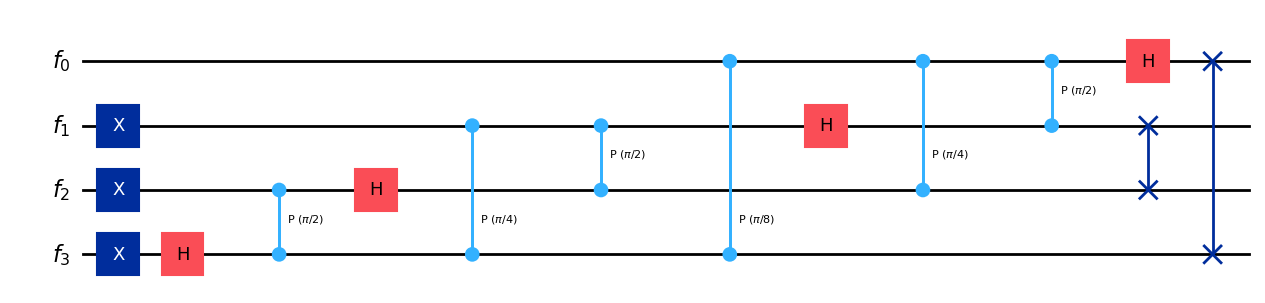

In [12]:
from qiskit.circuit.library import QFTGate

f = QuantumRegister(n, 'f')
qc_qiskit = QuantumCircuit(f, name='QFT Qiskit'+str(n))
qc_qiskit.append(encode_bin_value(bin_value), f[0:])
qc_qiskit.append(QFTGate(n), range(n))
qc_qiskit.decompose().draw('mpl', fold=30)

In [13]:
simulator = StatevectorSimulator()  # Create a simulator backend
transpiled_qc_qiskit = transpile(qc_qiskit, simulator)
result_qc_qiskit = simulator.run(transpiled_qc_qiskit).result()  # Run the circuit and get the result
statevector_qft_qiskit = result_qc_qiskit.get_statevector() 

In [14]:
print(statevector_qft_qiskit)
print(np.linalg.norm(np.asarray(statevector_qft) - np.asarray(statevector_qft_qiskit)))

Statevector([ 2.50000000e-01-6.12323400e-17j,
              2.50000000e-01-6.12323400e-17j,
             -2.50000000e-01+6.12323400e-17j,
             -2.50000000e-01+6.12323400e-17j,
             -7.65404249e-17-2.50000000e-01j,
             -7.65404249e-17-2.50000000e-01j,
              7.65404249e-17+2.50000000e-01j,
              7.65404249e-17+2.50000000e-01j,
              1.76776695e-01-1.76776695e-01j,
              1.76776695e-01-1.76776695e-01j,
             -1.76776695e-01+1.76776695e-01j,
             -1.76776695e-01+1.76776695e-01j,
             -1.76776695e-01-1.76776695e-01j,
             -1.76776695e-01-1.76776695e-01j,
              1.76776695e-01+1.76776695e-01j,
              1.76776695e-01+1.76776695e-01j],
            dims=(2, 2, 2, 2))
1.4102667888133162


In [15]:
def QFT_qiskitlike(n):
    q = QuantumRegister(n, 'q')
    qft_circuit = QuantumCircuit(q, name='QFT '+str(n))
    
    for i in range(len(q))[::-1]: ## Iterate over the qubits in reverse order as qiskit
        qft_circuit.append(HGate(), [q[i]])
        
        for k in range(i):
            controlled_phase_gate = CPhaseGate(pi/(2**(i-k)))
            qft_circuit.append(controlled_phase_gate, [q[k], q[i]])

    qft_circuit.barrier()
    for i in range(math.floor(len(q)/2)):
        qft_circuit.append(SwapGate(), [q[i], q[len(q)-i-1]])

    return qft_circuit

In [16]:
f = QuantumRegister(n, 'f')
qft_circuit = QuantumCircuit(f, name='QFT '+str(n))
qft_circuit.append(encode_bin_value(bin_value), f[0:])
qft_circuit.append(QFT_qiskitlike(len(f)), f[0:])


simulator = StatevectorSimulator()  # Create a simulator backend
transpiled_qft_circuit = transpile(qft_circuit, simulator)
result_qft = simulator.run(transpiled_qft_circuit).result()  # Run the circuit and get the result
statevector_qft = result_qft.get_statevector() 
print(np.linalg.norm(np.asarray(statevector_qft) - np.asarray(statevector_qft_qiskit)))

1.5700924586837752e-16


<h2>Check Correctness<h2>

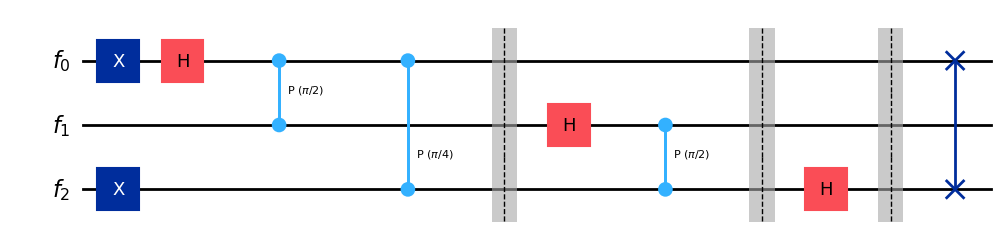

In [17]:
n = 3 
bin_value = '101'
f = QuantumRegister(n, 'f')
qft_circuit = QuantumCircuit(f, name='QFT '+str(n))
qft_circuit.append(encode_bin_value(bin_value), f[0:])
qft_circuit.append(QFT(len(f)), f[0:])

qft_circuit.decompose().draw('mpl', fold=30)

Binary Value: 101


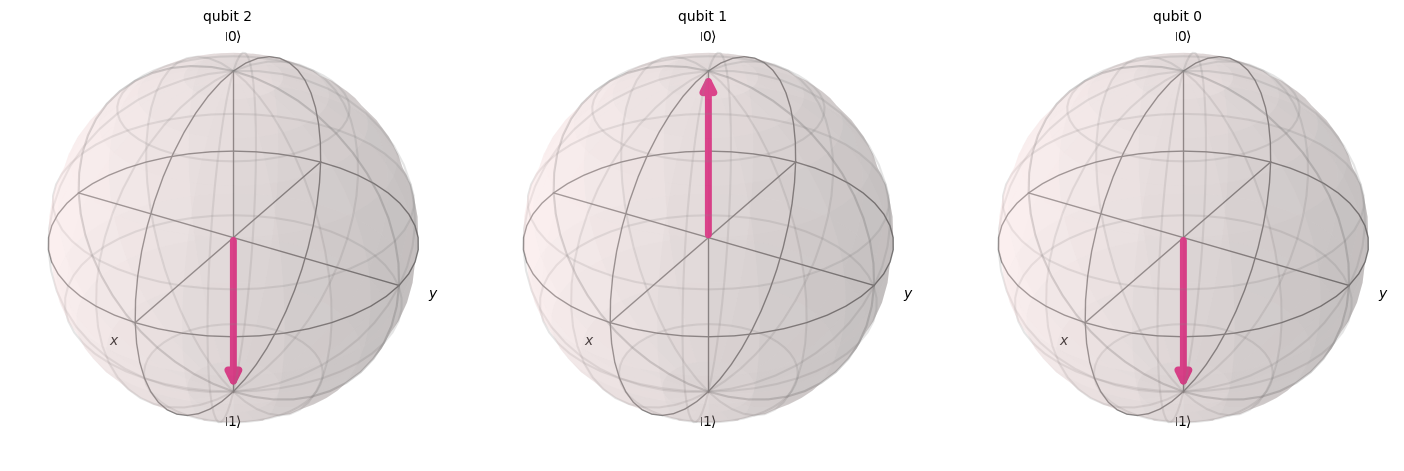

Binary Value in the Fourier basis:


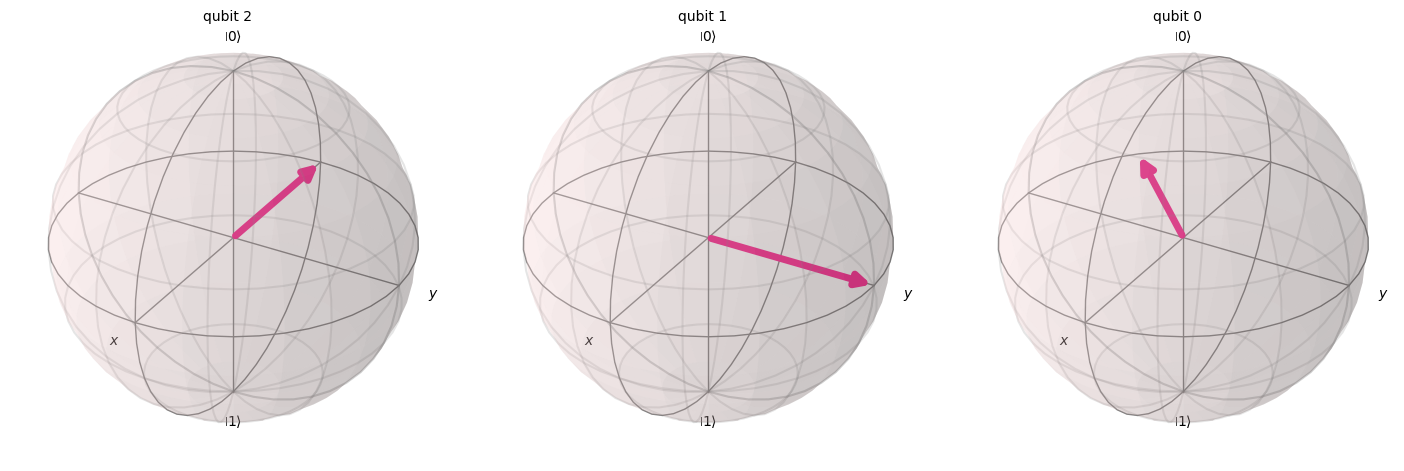

In [18]:
b = QuantumRegister(n, 'b')
qc_basis = QuantumCircuit(b, name='Basis '+str(n))
qc_basis.append(encode_bin_value(bin_value), b[0:])
simulator = StatevectorSimulator()  # Create a simulator backend
transpiled_qc_basis = transpile(qc_basis, simulator)
result_basis = simulator.run(transpiled_qc_basis).result()  # Run the circuit and get the result
statevector_basis = result_basis.get_statevector() 

f = QuantumRegister(n, 'f')
qft_circuit = QuantumCircuit(f, name='QFT '+str(n))
qft_circuit.append(encode_bin_value(bin_value), f[0:])
qft_circuit.append(QFT(len(f)), f[0:])
simulator = StatevectorSimulator()  # Create a simulator backend
transpiled_qft_circuit = transpile(qft_circuit, simulator)
result_qft = simulator.run(transpiled_qft_circuit).result()  # Run the circuit and get the result
statevector_qft = result_qft.get_statevector() 

print(f'Binary Value: {bin_value}')
display(plot_bloch_multivector(statevector_basis, reverse_bits=True))
print(f'Binary Value in the Fourier basis:')
display(plot_bloch_multivector(statevector_qft, reverse_bits=True))

In [19]:
# check correctness of stetevector against the expected Fourier transform of the input statevector
classical_ft = np.fft.ifft(statevector_basis) #ifft because we are using the inverse QFT, but the result is the same as the forward QFT up to a normalization factor and a complex conjugation, which does not affect the norm of the statevector
classical_ft = classical_ft / np.linalg.norm(classical_ft)  ## normalize the classical Fourier transform to compare with the quantum statevector

print(f'Classical Fourier Transform: {classical_ft}')
print(f'Actual Statevector: {statevector_qft}')
print(f'Difference: {np.linalg.norm(classical_ft - np.asarray(statevector_qft))}')

Classical Fourier Transform: [ 0.35355339+0.j         -0.25      -0.25j        0.        +0.35355339j
  0.25      -0.25j       -0.35355339+0.j          0.25      +0.25j
  0.        -0.35355339j -0.25      +0.25j      ]
Actual Statevector: Statevector([ 3.53553391e-01-4.32978028e-17j,
             -2.50000000e-01-2.50000000e-01j,
              6.49467042e-17+3.53553391e-01j,
              2.50000000e-01-2.50000000e-01j,
             -3.53553391e-01+4.32978028e-17j,
              2.50000000e-01+2.50000000e-01j,
             -6.49467042e-17-3.53553391e-01j,
             -2.50000000e-01+2.50000000e-01j],
            dims=(2, 2, 2))
Difference: 2.5561927685371326e-16


<h2>All basis states<h2>

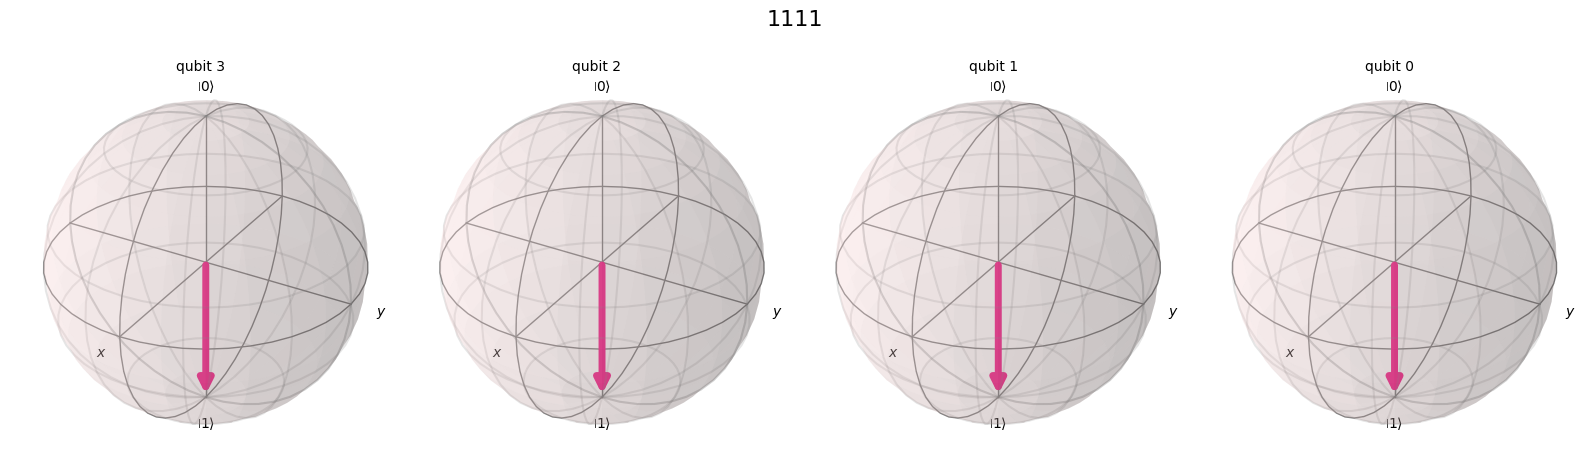

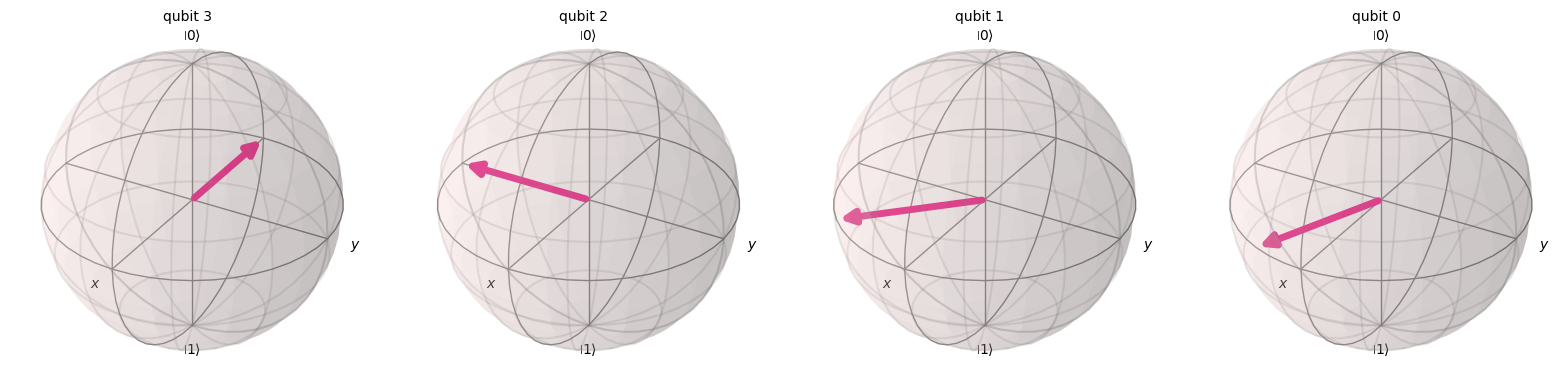

In [21]:
import time
from IPython.display import clear_output
from IPython.display import display
from qiskit.visualization import plot_bloch_vector,plot_bloch_multivector
%matplotlib inline

n = 16
digits = int(math.log2(n))

binary_values = []

for val in range(n):
    bin_str_pattern = '{:0%sb}' % digits     # create a pattern for binary string with leading zeros, e.g. for 4 digits it will be '{:04b}'
    bin_value = bin_str_pattern.format(val)  # format the integer value as a binary string using the pattern
    binary_values.append(bin_value)

print(binary_values)

simulator = StatevectorSimulator()  # Create a simulator backend

for bin_value in binary_values:
    comp_base_circuit = QuantumCircuit(digits)
    comp_base_circuit.append(encode_bin_value(bin_value), range(digits))
    comp_base_circuit_transpiled = transpile(comp_base_circuit, simulator)
    comp_base_statevector = simulator.run(comp_base_circuit_transpiled).result().get_statevector()


    fourier_base_circuit = QuantumCircuit(digits)
    fourier_base_circuit.append(encode_bin_value(bin_value), range(digits))
    fourier_base_circuit.append(QFT(digits), range(digits))
    fourier_base_circuit_transpiled = transpile(fourier_base_circuit, simulator)
    fourier_base_statevector = simulator.run(fourier_base_circuit_transpiled).result().get_statevector()


    clear_output(wait=True)
    display(plot_bloch_multivector(comp_base_statevector, title=bin_value, reverse_bits=True))
    display(plot_bloch_multivector(fourier_base_statevector, reverse_bits=True))
    time.sleep(0.5)

<h2> What happens when measuring? <h2>

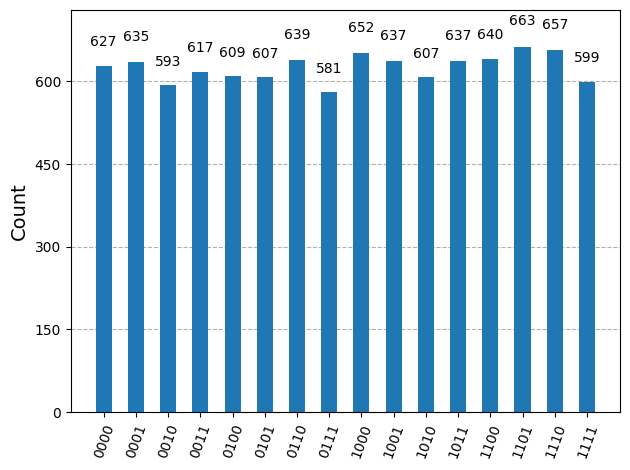

In [22]:
bin_value = '1010'
n = len(bin_value)

f = QuantumRegister(n, 'f')
qft_circuit = QuantumCircuit(f, name='QFT '+str(n))
qft_circuit.append(encode_bin_value(bin_value), f[0:])
qft_circuit.append(QFT(len(f)), f[0:])
qft_circuit.measure_all()

transpiled_qft_circuit = transpile(qft_circuit, simulator)
result = AerSimulator().run(transpiled_qft_circuit, shots=10000).result()  # Run the circuit and get the result

plot_histogram(result.get_counts())

# We get equal superposition of all the states, which is the expected result of the Fourier transform of a computational basis state.
# This is because the amplitudes of the statevector are all equal in magnitude, and the phases are such that they interfere constructively to give a uniform distribution over all the basis states.

In [23]:
# check that every amplitude in the state vector has the same magnitude
bin_value = '1010'
n = len(bin_value)

f = QuantumRegister(n, 'f')
qft_circuit = QuantumCircuit(f, name='QFT '+str(n))
qft_circuit.append(encode_bin_value(bin_value), f[0:])
qft_circuit.append(QFT(len(f)), f[0:])


simulator = StatevectorSimulator()  # Create a simulator backend
transpiled = transpile(qft_circuit, simulator)
result_qft = simulator.run(transpiled).result()  # Run the circuit and get the result
statevector = result_qft.get_statevector() 

print(statevector)

for amp in statevector:
    print(np.abs(amp))

Statevector([ 2.50000000e-01-6.12323400e-17j,
             -9.56708581e-02+2.30969883e-01j,
             -1.76776695e-01-1.76776695e-01j,
              2.30969883e-01-9.56708581e-02j,
              7.65404249e-17+2.50000000e-01j,
             -2.30969883e-01-9.56708581e-02j,
              1.76776695e-01-1.76776695e-01j,
              9.56708581e-02+2.30969883e-01j,
             -2.50000000e-01+6.12323400e-17j,
              9.56708581e-02-2.30969883e-01j,
              1.76776695e-01+1.76776695e-01j,
             -2.30969883e-01+9.56708581e-02j,
             -7.65404249e-17-2.50000000e-01j,
              2.30969883e-01+9.56708581e-02j,
             -1.76776695e-01+1.76776695e-01j,
             -9.56708581e-02-2.30969883e-01j],
            dims=(2, 2, 2, 2))
0.25
0.2499999999999999
0.25000000000000006
0.24999999999999994
0.24999999999999994
0.24999999999999986
0.24999999999999994
0.24999999999999997
0.25000000000000006
0.24999999999999994
0.25000000000000006
0.25
0.25
0.2499999999999999

/var/folders/sp/ts4mbctd14xd1glwp1q61sj40000gn/T/ipykernel_63876/3960322111.py:18: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  for amp in statevector:


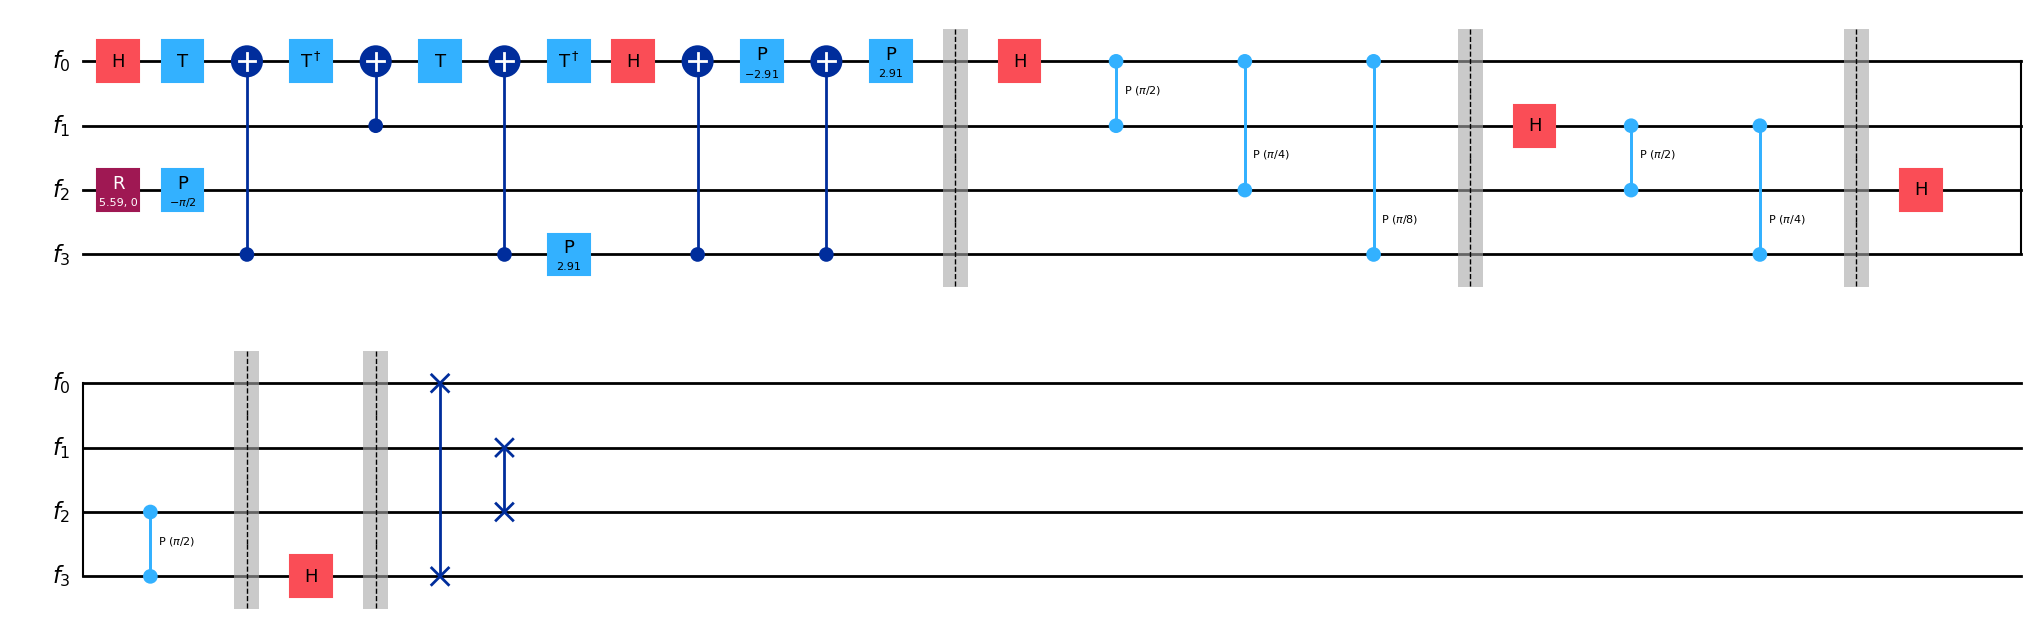

In [24]:
## apply qft to random circuit (no basis state)
from qiskit.circuit.random import random_circuit

circ = random_circuit(n, 2, seed=123, measure=False)

f = QuantumRegister(n, 'f')
qft_circuit = QuantumCircuit(f, name='QFT '+str(n))
qft_circuit.compose(circ, inplace=True)
qft_circuit.barrier()
qft_circuit.append(QFT(len(f)), f[0:])

qft_circuit.decompose().draw('mpl', fold=30)


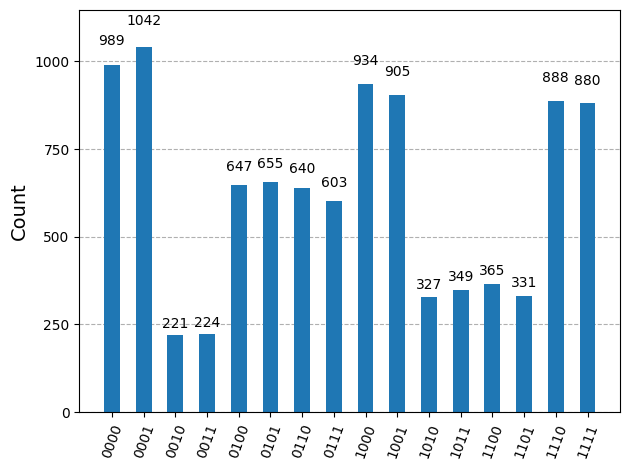

In [25]:
qft_circuit.measure_all()
transpiled_qft_circuit = transpile(qft_circuit, simulator)
result = AerSimulator().run(transpiled_qft_circuit, shots=10000).result()  # Run the circuit and get the result

plot_histogram(result.get_counts())

# QUANTUM PHASE ESTIMATION

The goal is to estimates the phase $ \theta\ $ in  

$$
U|\psi\rangle = e^{i \theta}|\psi\rangle,
$$

where $ |\psi\rangle\ $ is an eigenstate of a unitary $ U $.

In practice, QPE uses:
- **counting qubits** (to store phase information),
- **controlled powers of** $ U $ (to encode the phase),
- **inverse QFT** (to decode the phase into a binary estimate).

The measurement outcome gives an approximation of $ \theta\ $, with accuracy improving as the number of counting qubits increases.

## Set Up: angle & counting qubits

In [26]:
#Here you can insert the phase (=angle), you wish to encode.
angle = pi/4 #The phase angle we wish to encode: QPE estimates φ where θ = 2πφ
actual_phase = angle/(2*pi)  #This is the actual phase rotation (We use this value to check the answer)
# val =  (pi/4)/(2*pi) = 1/8 = 0.125 which in binary is 0.001 (1*2^-3)
precision = 3 #precision (a.k.a counting qubits)

For this example, choose

$$
U=\begin{pmatrix}
1 & 0\\
0 & e^{i\theta}
\end{pmatrix}.
$$

This unitary is diagonal, so its eigenvectors are computational-basis states. In particular, $ \lvert 1\rangle\ $ is an eigenvector with eigenvalue $ e^{i\theta}\ $

# Without QPE

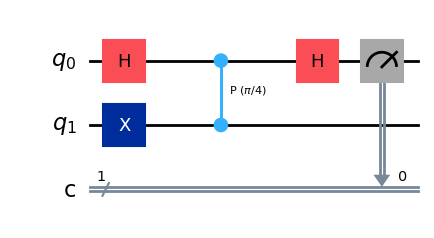

In [35]:
# Hadamard test
qc = QuantumCircuit(2, 1)
qc.x(1) # prepare the eigenstate |1> of the unitary U
qc.h(0)
qc.cp(angle, 0, 1) # apply the controlled unitary (in this case a controlled phase shift)
qc.h(0)
qc.measure(0, 0)

qc.draw('mpl')

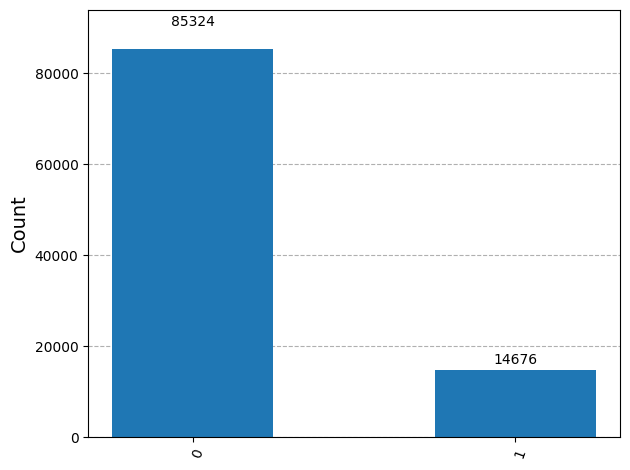

In [ ]:
simulator = AerSimulator()  # Create a simulator backend
result = simulator.run(qc, shots=1000).result()  #
plot_histogram(result.get_counts())

In [47]:
# retrieve the estimated phase from the measurement results
counts = result.get_counts()
prob_0 = counts.get('0', 0) / sum(counts.values())  # probability of measuring '0' gives us the estimate of cos^2(θ/2), from which we can derive an estimate of θ and thus φ
estimated_phase = np.arccos(np.sqrt(prob_0)) * 2 / (2*np.pi)  # convert the probability to an estimate of the phase φ
print(f'Estimated Phase (from Hadamard test): {estimated_phase}')
print(f'Actual Phase: {actual_phase}')

Estimated Phase (from Hadamard test): 0.12514101288126492
Actual Phase: 0.125


# With QPE

## STEP 1

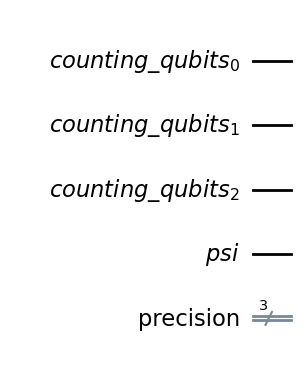

In [48]:
cq = QuantumRegister(precision, 'counting_qubits')
psi = QuantumRegister(1, 'psi')
cc = ClassicalRegister(precision, 'precision')
circuit = QuantumCircuit(cq, psi, cc)

circuit.draw(output='mpl')

## STEP 2

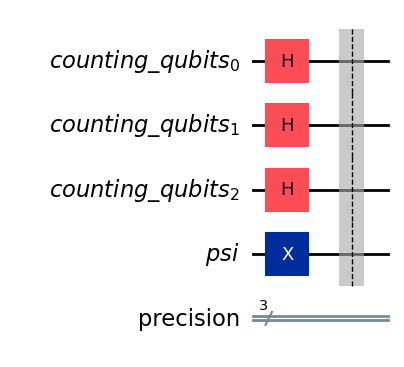

In [49]:
#Superpose counting qubits
for q in cq:
    circuit.append(HGate(), [q])

# |psi> = 0 --> X|psi> = 1 (eigenvector of any PhaseGate)
circuit.append(XGate(), [psi])
circuit.barrier()

circuit.draw(output='mpl')

## STEP 3

In [50]:
def Inverse_QFT(n):
    q = QuantumRegister(n, 'q')
    qft_circuit = QuantumCircuit(q, name='Inverse_QFT '+str(n))
    
    for i in range(math.floor(len(q)/2)):
        qft_circuit.append(SwapGate(), [q[i], q[len(q)-i-1]])


    for i in range(len(q)):
        for j in range(i):
            controlled_phase_gate = CPhaseGate(-pi/(2**(i-j)))
            qft_circuit.append(controlled_phase_gate, [q[j], q[i]])
        qft_circuit.append(HGate(), [q[i]])
    
    return qft_circuit

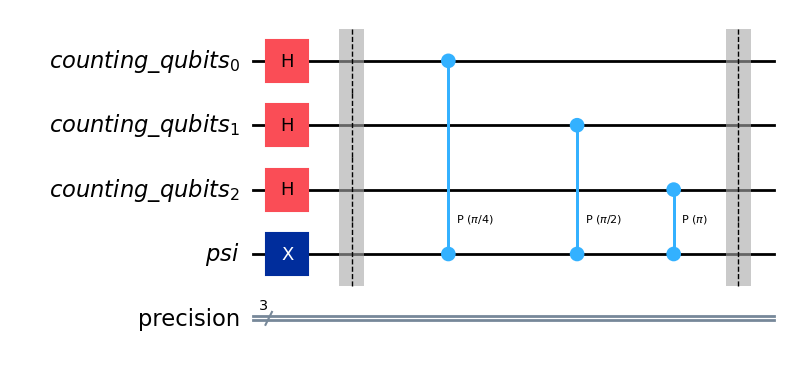

In [51]:
##----- Encoding in the Fourier Basis the phase -----#
for i in range(len(cq)):
    unitary = CPhaseGate(angle*(2**i))
    circuit.append(unitary, [cq[i], psi])
        
circuit.barrier()
circuit.draw(output='mpl')

## STEP 4

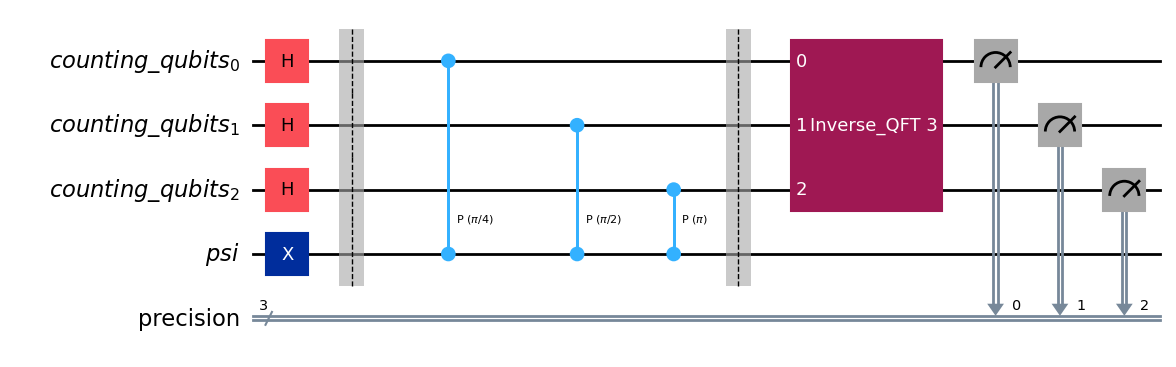

In [52]:
#----- Inverse QFT -----#
circuit.append(Inverse_QFT(len(cq)), cq[0:])

circuit.measure(cq, cc)
circuit.draw(output='mpl')

# Simulate

In [53]:
simulator = AerSimulator()  # Create a simulator backend
transpiled_circuit = transpile(circuit, simulator)
counts = simulator.run(transpiled_circuit, shots=1).result().get_counts()   # Run the circuit and get the result

print("Phase estimation output")
print("-----------------------")

a = counts.most_frequent()
print("Most frequent measurement:", a, "\n")
bin_a = int(a,2) #Converts the binary value to an integer
#(Note that the QPE outputs |2^(len(cq))*angle). So. to obtaing the angle (phase) --> bin_a/(2**len(cq))
phase = bin_a/(2**len(cq)) #The calculation used to estimate the phase 

print("ESTIMATED: ", phase)
print("ACTUAL: ", actual_phase) 

print("Error: ", abs(actual_phase - phase))  # <-- Error != 0, if the number of counting qubits (precision) is not enough to represent the phase in the computational basis

Phase estimation output
-----------------------
Most frequent measurement: 001 

ESTIMATED:  0.125
ACTUAL:  0.125
Error:  0.0


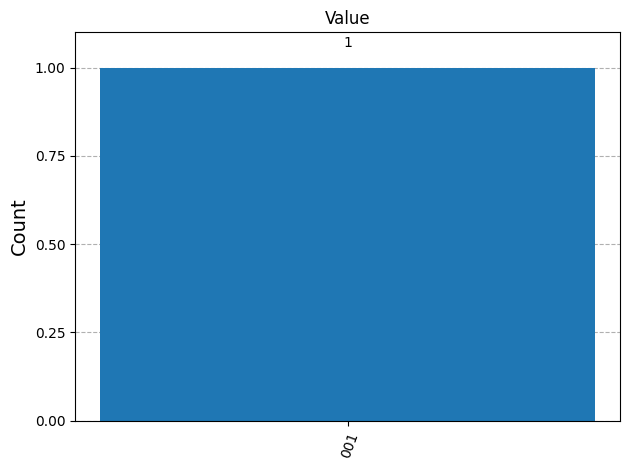

In [54]:
plot_histogram(counts, title="Value")

<h2>Different Angles<h2>

Phase estimation output
-----------------------
Most frequent measurement: 001 

ESTIMATED:  0.125
ACTUAL:  0.16666666666666666
Error:  0.04166666666666666


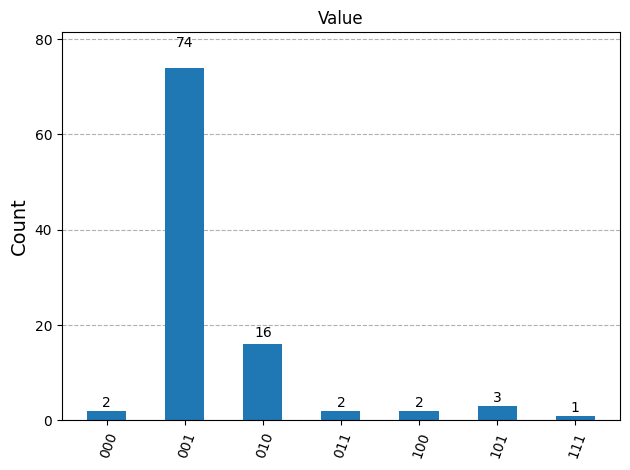

In [55]:
#Here you can insert the phase (=angle), you wish to encode.
angle = pi/3 #The phase angle we wish to encode

actual_phase = angle/(2*pi)  #This is the actual phase rotation (We use this value to check the answer)
# val =  (pi/3)/(2*pi) = 1/6 = 0.16666666666666666 which in binary is 0.001010101010101... (1*2^-3 + 1*2^-5 + 1*2^-7 + ...) periodic!

precision = 3 #precision (a.k.a counting qubits)

cq = QuantumRegister(precision, 'counting_qubits')
psi = QuantumRegister(1, 'psi')
cc = ClassicalRegister(precision, 'precision')
circuit = QuantumCircuit(cq, psi, cc)

#Superpose counting qubits
for q in cq:
    circuit.append(HGate(), [q])

# |psi> = 0 --> X|psi> = 1 (eigenvector of any PhaseGate)
circuit.append(XGate(), [psi])
circuit.barrier()


##----- Encoding in the Fourier Basis the phase -----#
for i in range(len(cq)):
    unitary = CPhaseGate(angle*(2**i))
    circuit.append(unitary, [cq[i], psi])
        
circuit.barrier()

#----- Inverse QFT -----#
circuit.append(Inverse_QFT(len(cq)), cq[0:])

circuit.measure(cq, cc)

simulator = AerSimulator()  # Create a simulator backend
transpiled_circuit = transpile(circuit, simulator)
counts = simulator.run(transpiled_circuit, shots=100).result().get_counts()   # Run the circuit and get the result

print("Phase estimation output")
print("-----------------------")

a = counts.most_frequent()
print("Most frequent measurement:", a, "\n")
bin_a = int(a,2) #Converts the binary value to an integer
#(Note that the QPE outputs |2^(len(cq))*angle). So. to obtaing the angle (phase) --> bin_a/(2**len(cq))
phase = bin_a/(2**len(cq)) #The calculation used to estimate the phase 

print("ESTIMATED: ", phase)
print("ACTUAL: ", actual_phase) 

print("Error: ", abs(actual_phase - phase))  # <-- Error != 0, if the number of counting qubits (precision) is not enough to represent the phase in the computational basis

plot_histogram(counts, title="Value")


# QISKIT LIBRARY

In [56]:
from qiskit.circuit.library import PhaseEstimation, PhaseGate, TGate
angle = pi/4 #The phase angle we wish to encode


/var/folders/sp/ts4mbctd14xd1glwp1q61sj40000gn/T/ipykernel_63876/481179670.py:17: DeprecationWarning: The class ``qiskit.circuit.library.phase_estimation.PhaseEstimation`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.phase_estimation instead.
  circuit_qiskit.append(PhaseEstimation(len(cq), unitary), cq[0:]+psi[0:])


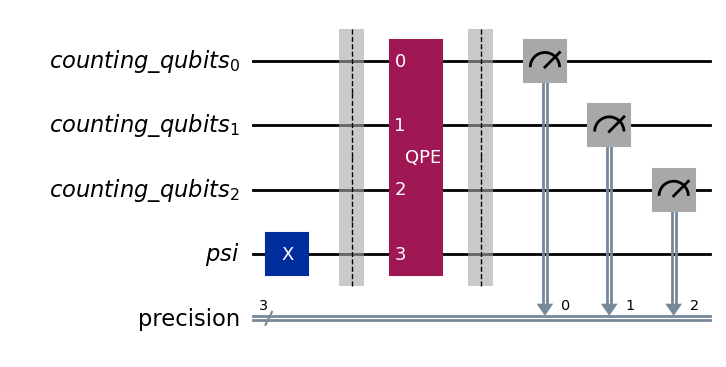

In [57]:
#--------------STEP 1--------------
cq = QuantumRegister(precision, 'counting_qubits')
psi = QuantumRegister(1, 'psi')
cc = ClassicalRegister(precision, 'precision')
circuit_qiskit = QuantumCircuit(cq, psi, cc)


#--------------STEP 2--------------
# |psi> = 0 --> X|psi> = 1 (eigenvector of any PhaseGate)
circuit_qiskit.append(XGate(), [psi])
circuit_qiskit.barrier()



#------------STEP 3 & 4------------
unitary = PhaseGate(4*angle)
circuit_qiskit.append(PhaseEstimation(len(cq), unitary), cq[0:]+psi[0:])
circuit_qiskit.barrier()

circuit_qiskit.measure(cq, cc)


circuit_qiskit.draw(output='mpl')

In [58]:
simulator = AerSimulator()  # Create a simulator backend
transpiled_circuit_qiskit = transpile(circuit_qiskit, simulator)
counts = simulator.run(transpiled_circuit_qiskit, shots=8192).result().get_counts()   # Run the circuit and get the result

print("Phase estimation output")
print("-----------------------")

a = counts.most_frequent()
print("Most frequeant measurement:", a, "\n")
bin_a = int(a,2) #Converts the binary value to an integer

#(Note that the QPE outputs |2^(len(cq))*angle). So. to obtaing the angle (phase) --> bin_a/(2**len(cq))
phase = bin_a/(2**len(cq)) #The calculation used to estimate the phase 

print("ESTIMATED: ", phase)
print("ACTUAL: ", actual_phase) 



Phase estimation output
-----------------------
Most frequeant measurement: 001 

ESTIMATED:  0.125
ACTUAL:  0.16666666666666666
